# Load packages

Read in all necessary packages:

In [2]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scanpy as sc
import numpy as np
import decoupler as dc

plt.set_loglevel('WARNING') 

In [3]:
import decoupler as dc

In [13]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

# Load the dataset

## load adata file and define groups for differential expression

In [5]:
adata = sc.read_h5ad('../../../tchic_local/fig6_build/legacy/data/20230704_adata_all.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_genes', 'S_score', 'G2M_score', 'phase', 'enrichment', 'coverage', 'QC', 'pseudotime', 'pseudotime2'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'old_celltype_colors', 'old_leiden_general_colors', 'old_leiden_merge_colors', 'pca', 'phase_colors', 'predicted_final_colors', 'predicted_id_E75_colors', 'predicted_id_E85_colors', 'replicates_colors', 'umap', 'umap_density_mark_par

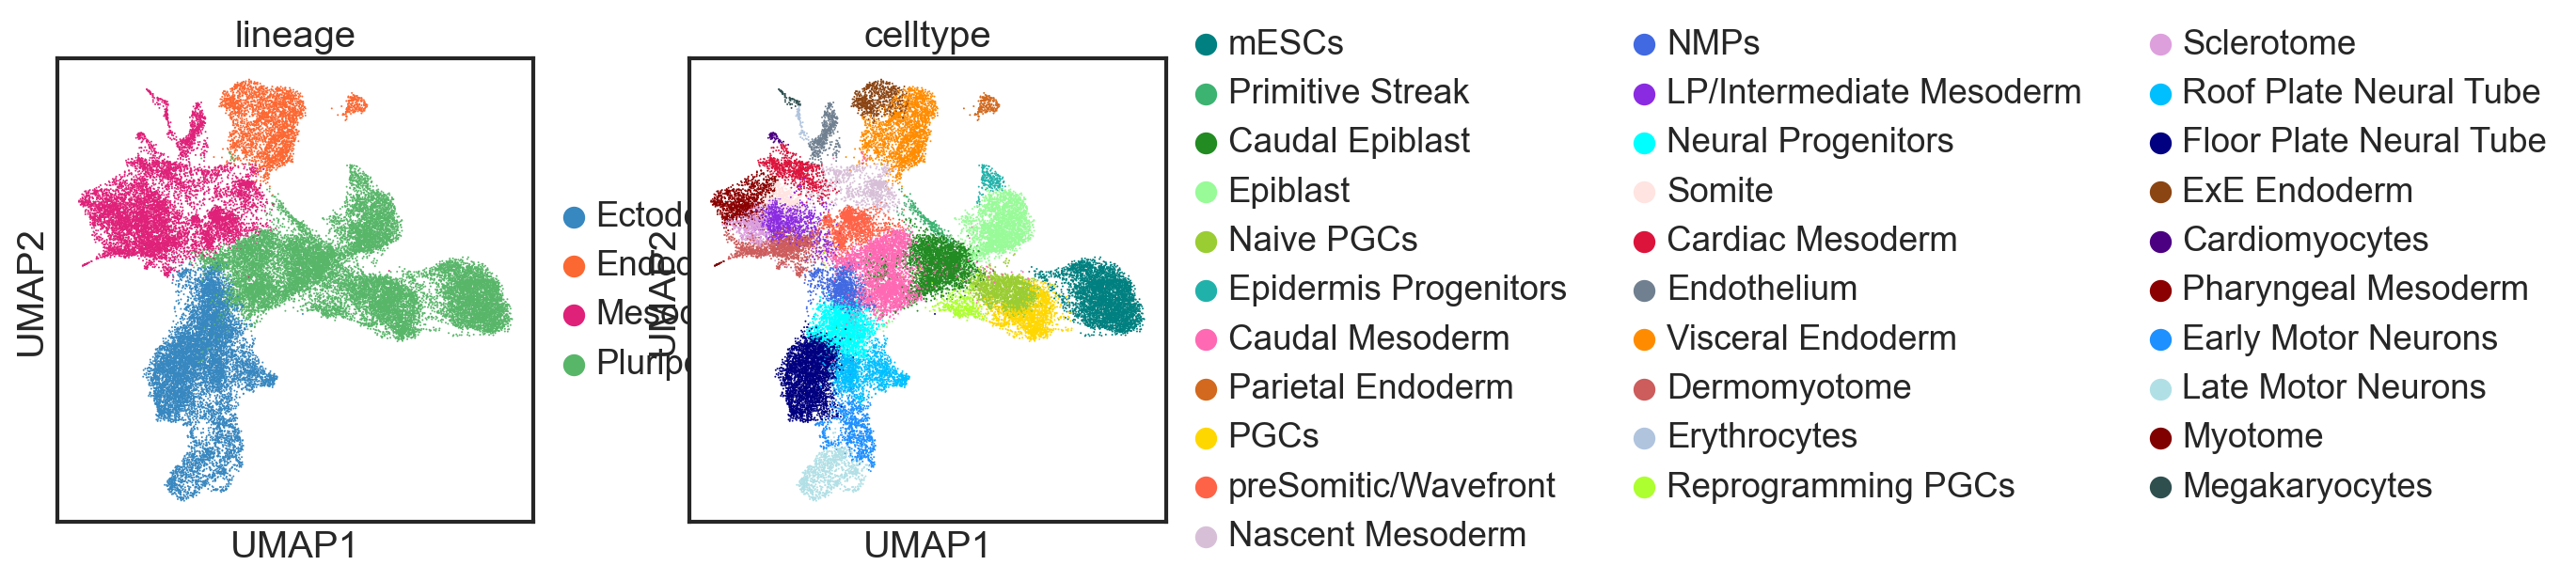

In [6]:
sc.pl.umap(adata, color = ['lineage', 'celltype'])

In [7]:
sc.settings.verbosity = 2

## load the tables with differentially expressed genes

In [8]:
PvsDIFF = pd.read_csv('dfs/20250303_diff_genes_PvsDIFF.csv')
ESCvsP = pd.read_csv('dfs/20250303_diff_genes_ESCvsP.csv')
PvsECT = pd.read_csv('dfs/20250303_diff_genes_PvsECT.csv')
PvsEND = pd.read_csv('dfs/20250303_diff_genes_PvsEND.csv')
PvsMES = pd.read_csv('dfs/20250303_diff_genes_PvsMES.csv')

In [9]:
def up_down_genes(results_df):
    up = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] > 2)].sort_values(by = 'log2FoldChange',ascending=True)
    down = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] < -2)].sort_values(by = 'log2FoldChange',ascending=True)
    return up,down


In [10]:
PvsDIFF_up, PvsDIFF_down = up_down_genes(PvsDIFF)
ESCvsP_up, ESCvsP_down = up_down_genes(ESCvsP)
PvsECT_up, PvsECT_down = up_down_genes(PvsECT)
PvsEND_up, PvsEND_down = up_down_genes(PvsEND)
PvsMES_up, PvsMES_down = up_down_genes(PvsMES)

# Plotting gene sets

## venn diagrams: check intersect between genesets

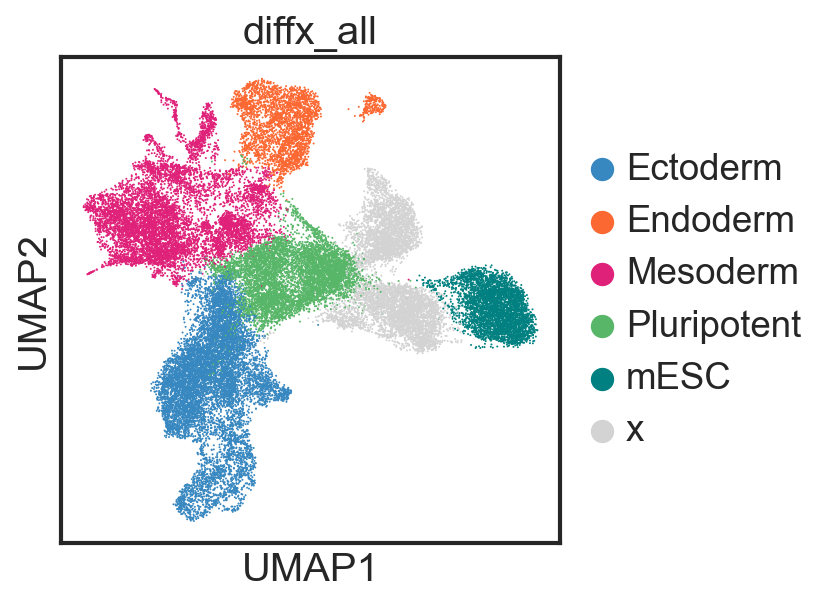

In [15]:
dict_ct = {'Mesoderm':'Mesoderm',
 'Ectoderm':'Ectoderm',
 'Endoderm':'Endoderm',
           'Pluripotent':'Pluripotent'}

adata.obs['diffx_all'] = (
    adata.obs["lineage"]
    .map(lambda x: dict_ct.get(x, x))
    .astype("category")
)

adata.obs['diffx_all'] = adata.obs['diffx_all'].astype(str)
adata.obs.loc[list(adata[adata.obs['celltype'] == 'mESCs'].obs.index), 'diffx_all'] = 'mESC'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'PGCs'].obs.index), 'diffx_all'] = 'x'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'Epidermis Progenitors'].obs.index), 'diffx_all'] = 'x'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'Epiblast'].obs.index), 'diffx_all'] = 'x'

cols = ['#3787c0', '#fc6832','#df2179', '#58b669','teal','lightgrey']
sc.pl.umap(adata, color = 'diffx_all', palette = cols )
color_pal = dict(zip(adata.obs['diffx_all'].cat.categories,adata.uns[str('diffx_all') + '_colors']))


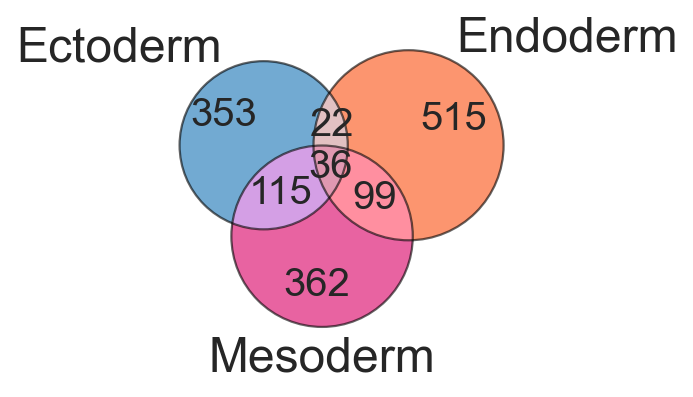

In [37]:
from matplotlib_venn import venn3, venn3_circles

A = PvsECT_up['Gene']
B = PvsEND_up['Gene']
C = PvsMES_up['Gene']

fig,ax = plt.subplots(figsize = (3,3))
venn3([set(A),set(B),set(C)],ax=ax, set_colors = list(color_pal.values())[0:3],set_labels = list(color_pal.keys())[0:3],
      alpha = 0.7)
c = venn3_circles([set(A),set(B),set(C)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)

#plt.savefig('figs/20250305_venn_overlap_lineages_up.png',bbox_inches='tight')
plt.show()

In [17]:
sc.set_figure_params(dpi = 80)

sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

In [18]:
cols[0]

'#3787c0'

# Take only unique differentially expressed genes

For the lineages, we take the "up" fraction - these are upregulated in lin vs pluripotent. \
For pluripotency, we take the "down" fraction in p vs diff - these are downregulated in the lineages compared to pluripotency, i.e. they are up in pluripotency. \
For ESCs, we take the "down" fraction in ESC vs p - these are donwregulated in ESCs compared to P. The "up" fraction is differentially expresssed in pluripotent compared to ESCs.

In [19]:
ecto = PvsECT_up[~PvsECT_up['Gene'].isin(list(PvsEND_up['Gene']) + list(PvsMES_up['Gene']))]
meso = PvsMES_up[~PvsMES_up['Gene'].isin(list(PvsEND_up['Gene']) + list(PvsECT_up['Gene']))]
endo = PvsEND_up[~PvsEND_up['Gene'].isin(list(PvsECT_up['Gene']) + list(PvsMES_up['Gene']))]
pluri = PvsDIFF_down

In [20]:
metadata = pd.read_csv('../../../tchic_local/fig6_build/dfs/20250215_metadata.tsv', index_col = 0, header = 0, low_memory= False, sep = '\t')

In [21]:
metadata.head(2)

,step,PT,UMAP1,UMAP2,lin,RT,lin2,RT_m,step_id
1,1,0.372537,11.126464,4.599585,ect1,mESCs,Pluripotent mESCs,0.0,1:ect1
2,2,0.463342,11.385221,4.509028,ect1,mESCs,Pluripotent mESCs,0.0,2:ect1


In [22]:
pwd

'/Users/mbloten1/Library/CloudStorage/OneDrive-UniversitédeLausanne/Documents/jupyter_default/2025/tchic_figures/fig6/diff_gene_analysis'

In [23]:
count_table = pd.read_csv('../../../tchic_local/fig6_build/dfs/20250304_count_data_all_thresh_min.tsv', sep = '\t', index_col = 0)

In [24]:
count_table.index = count_table['gene']
count_table.head(2)

,gene,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn
gene,,,,,,,,,,
Xkr4,Xkr4,1,RNA,0.25,ect1,0.284,-1.943416,-1.766112,1.0,0.0
Rp1,Rp1,1,RNA,0.23,ect1,0.278,-2.058894,-1.795859,1.0,1.0


In [25]:
d_rna = {}
d_k4 = {}
d_k27 = {}
df_rna = count_table[count_table['layer'] == 'RNA']
df_k4 = count_table[count_table['layer'] == 'K4']
df_k27 = count_table[count_table['layer'] == 'K27']

df_rna = df_rna.drop('gene',axis=1)
df_k4 = df_k4.drop('gene',axis=1)
df_k27 = df_k27.drop('gene',axis=1)

In [26]:
df_rna['p_99'] = df_rna['sm_short']/np.percentile(df_rna['sm_short'],99)
df_k4['p_99'] = df_k4['sm_short']/np.percentile(df_k4['sm_short'],99)
df_k27['p_99'] = df_k27['sm_short']/np.percentile(df_k27['sm_short'],99)

df_rna['p_98'] = df_rna['sm_short']/np.percentile(df_rna['sm_short'],98)
df_k4['p_98'] = df_k4['sm_short']/np.percentile(df_k4['sm_short'],98)
df_k27['p_98'] = df_k27['sm_short']/np.percentile(df_k27['sm_short'],98)

df_rna['p_95'] = df_rna['sm_short']/np.percentile(df_rna['sm_short'],95)
df_k4['p_95'] = df_k4['sm_short']/np.percentile(df_k4['sm_short'],95)
df_k27['p_95'] = df_k27['sm_short']/np.percentile(df_k27['sm_short'],95)

In [27]:
ct_normalised = pd.concat([df_rna,df_k4,df_k27])

In [28]:
ct_normalised.head(2)

,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,p_99,p_98,p_95
gene,,,,,,,,,,,,
Xkr4,1,RNA,0.25,ect1,0.284,-1.943416,-1.766112,1.0,0.0,0.047819,0.069934,0.125110
Rp1,1,RNA,0.23,ect1,0.278,-2.058894,-1.795859,1.0,1.0,0.046809,0.068456,0.122467


In [29]:
ct_normalised['p98_log2'] = np.log2(ct_normalised['p_98']+1)
ct_normalised['p98_log10'] = np.log10(ct_normalised['p_98']+1)

ct_normalised['step_id'] = ct_normalised['step'].astype(str) + str(':') + ct_normalised['lin']
metadata['step_id'] = metadata['step'].astype(str) + str(':') + metadata['lin']
steps_to_RT = metadata[['step_id','RT']].set_index('step_id').to_dict()['RT']
ct_normalised['RT'] = ct_normalised['step_id'].map(steps_to_RT)
ct_normalised['RT'] = ct_normalised['RT'].astype('category')
ct_normalised['RT'] = ct_normalised['RT'].cat.reorder_categories(['mESCs','Gastd3', 'Gastd4', 'Gastd5', 'Gastd6', 'Gastd7'])
ct_normalised['lin_layer'] = ct_normalised['lin'].astype(str) + str('_') + ct_normalised['layer'].astype(str)


In [30]:
ct_normalised.head(2)

,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,p_99,p_98,p_95,p98_log2,p98_log10,step_id,RT,lin_layer
gene,,,,,,,,,,,,,,,,,
Xkr4,1,RNA,0.25,ect1,0.284,-1.943416,-1.766112,1.0,0.0,0.047819,0.069934,0.125110,0.097521,0.029357,1:ect1,mESCs,ect1_RNA
Rp1,1,RNA,0.23,ect1,0.278,-2.058894,-1.795859,1.0,1.0,0.046809,0.068456,0.122467,0.095528,0.028757,1:ect1,mESCs,ect1_RNA


In [31]:
to_plot1 = ct_normalised.loc[list(set(endo['Gene']) & set(ct_normalised.index))]
to_plot2 = ct_normalised.loc[list(set(meso['Gene']) & set(ct_normalised.index))]
to_plot3 = ct_normalised.loc[list(set(ecto['Gene']) & set(ct_normalised.index))]
to_plot4 = ct_normalised.loc[list(set(pluri['Gene']) & set(ct_normalised.index))]

In [32]:
lin_colors = {'Ectoderm':'#3787C0', 'Endoderm':'#FC6832', 'Mesoderm':'#DF2179'}
Green='#238b45'
Purple='#6a51a3'
Orange='#d94801'

lightOrange = '#f59c71'
lightGreen = '#90f5b1'
lightPurple = '#b698fa'

# identify state changes

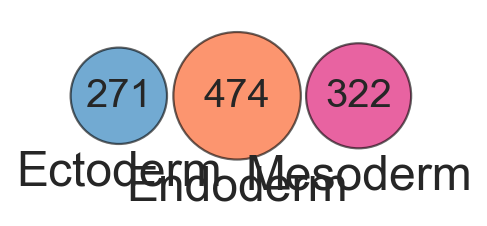

In [40]:
# sanity check
rom matplotlib_venn import venn3, venn3_circles

A = to_plot3.index.unique()
B = to_plot1.index.unique()
C = to_plot2.index.unique()

fig,ax = plt.subplots(figsize = (3,3))
venn3([set(A),set(B),set(C)],ax=ax, set_colors = list(color_pal.values())[0:3],set_labels = list(color_pal.keys())[0:3],
      alpha = 0.7)
c = venn3_circles([set(A),set(B),set(C)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)

#plt.savefig('figs/20250305_venn_overlap_lineages_up.png',bbox_inches='tight')
plt.show()

In [302]:
def findStateChanges(df, state = 'sm_short_state_dyn', val = 'sm_short'):
    df = df.reset_index().set_index(['step','gene','layer','lin'])
    df2 = df.copy()
    idx =df2.reset_index()['step']+1
    df2 = df2.reset_index().set_index([idx,'gene','layer','lin'])

    #add change
    df['change'] = df[state] - df2[state]
    #add val change compared to step-1
    df['val_change'] = df[val] - df2[val]
    #add val change compared to step 1

    #extract the number of steps per trajectory
    dict1 = {}
    for x in df2['lin_layer'].unique():
        dict1[x] = df2[df2['lin_layer'] == x]['step'].max()
    #take all values for step 1
    steps_1 = df2[df2['step'] == 1][[val,'lin_layer']]
    # add total n steps per trajectory 
    steps_1['counts'] = steps_1['lin_layer'].replace(dict1)

    # multiply step 1 by length of trajectory
    all_steps_1 = []
    for num in range(steps_1.shape[0]):
        all_steps_1.extend([steps_1[val].iloc[num]]* steps_1['counts'].iloc[num])

    # add all step 1s as a column
    df['steps1'] = all_steps_1
    #substract value of step n from value of step 1
    df['total_change'] = df['steps1'] - df[val]
    
    return df[df['change'] != 0].dropna().reset_index()

    

In [303]:
end_changes = findStateChanges(to_plot1.drop(['p_99','p_98', 'p_95', 'p98_log2', 'p98_log10', 'step_id'], axis = 1),state = 'sm_short_state_fix')
end_changes.head(2)

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_1833/3260040972.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  steps_1['counts'] = steps_1['lin_layer'].replace(dict1)


,step,gene,layer,lin,counts,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,RT,lin_layer,it,change,val_change,steps1,total_change
0,11,Slc39a8,RNA,ect1,0.03,0.016,-4.643856,-5.265345,0.0,0.0,mESCs,ect1_RNA,ect1_RNA_Slc39a8,-1.0,-0.002,0.032,0.016
1,16,Slc39a8,RNA,ect1,0.00,0.017,-6.643856,-5.210897,1.0,0.0,mESCs,ect1_RNA,ect1_RNA_Slc39a8,1.0,0.001,0.032,0.015


In [304]:
mes_changes = findStateChanges(to_plot2.drop(['p_99','p_98', 'p_95', 'p98_log2', 'p98_log10', 'step_id'], axis = 1),state = 'sm_short_state_fix')
mes_changes.head(2)

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_1833/3260040972.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  steps_1['counts'] = steps_1['lin_layer'].replace(dict1)


,step,gene,layer,lin,counts,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,RT,lin_layer,change,val_change,steps1,total_change
0,33,Hgf,RNA,ect1,0.03,0.016,-4.643856,-5.265345,0.0,0.0,mESCs,ect1_RNA,-1.0,-0.002,0.028,0.012
1,34,Hgf,RNA,ect1,0.03,0.020,-4.643856,-5.058894,1.0,0.0,mESCs,ect1_RNA,1.0,0.004,0.028,0.008


In [330]:
ect_changes = findStateChanges(to_plot3.drop(['p_99','p_98', 'p_95', 'p98_log2', 'p98_log10', 'step_id'], axis = 1),state = 'sm_short_state_dyn')
ect_changes.head(2)

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_1833/3260040972.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  steps_1['counts'] = steps_1['lin_layer'].replace(dict1)


,step,gene,layer,lin,counts,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,RT,lin_layer,change,val_change,steps1,total_change
0,141,Syt2,RNA,ect1,0.33,0.426,-1.556393,-1.19760,1.0,1.0,Gastd7,ect1_RNA,1.0,0.064,0.094,-0.332
1,157,Syt2,RNA,ect3,0.34,0.401,-1.514573,-1.28279,1.0,1.0,Gastd7,ect3_RNA,1.0,0.016,0.094,-0.307


In [306]:
p_changes = findStateChanges(to_plot4.drop(['p_99','p_98', 'p_95', 'p98_log2', 'p98_log10', 'step_id'], axis = 1),state = 'sm_short_state_fix')
p_changes.head(2)

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_1833/3260040972.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  steps_1['counts'] = steps_1['lin_layer'].replace(dict1)


,step,gene,layer,lin,counts,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,RT,lin_layer,change,val_change,steps1,total_change
0,39,Ccnb1ip1,K27,ect1,0.14,0.096,-2.736966,-3.237864,0.0,1.0,Gastd4,ect1_K27,-1.0,-0.010667,0.115,0.019
1,39,Ccnb1ip1,K27,ect2,0.14,0.096,-2.736966,-3.237864,0.0,1.0,Gastd4,ect2_K27,-1.0,-0.010667,0.115,0.019


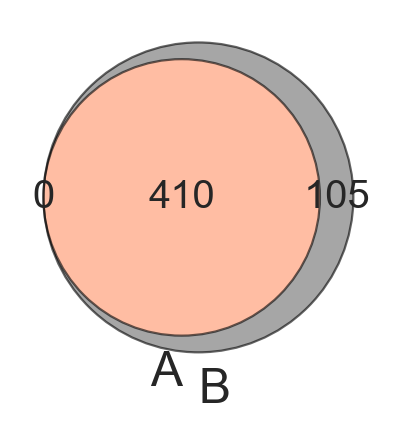

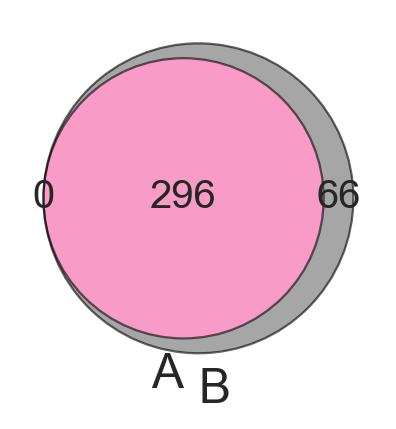

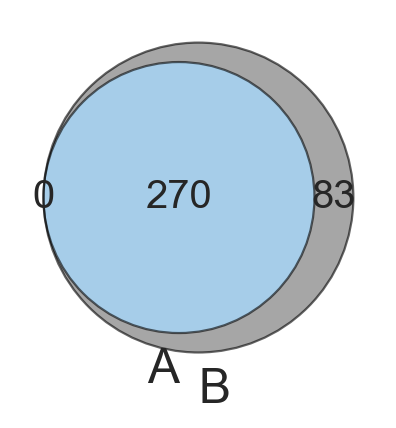

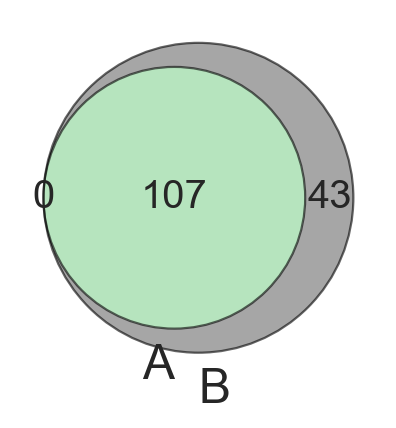

In [331]:
# sanity check
from matplotlib_venn import venn2, venn2_circles

lists = [[end_changes['gene'].unique(), endo['Gene'].unique()], 
         [mes_changes['gene'].unique(), meso['Gene'].unique()],
         [ect_changes['gene'].unique(), ecto['Gene'].unique()],
         [p_changes['gene'].unique(), pluri['Gene'].unique()],
        ]
cols = ['#fc6832','#df2179','#3787c0','#58b669']

for num,sets in enumerate(lists):
    fig,ax = plt.subplots(figsize = (3,3))
    venn2([set(sets[0]),set(sets[1])],ax=ax, set_colors = [cols[num],'grey'],
          alpha = 0.7)
    c = venn2_circles([set(sets[0]),set(sets[1])],color = 'black',linewidth = 1,ax=ax, 
          alpha = 0.6)
    plt.show()

In [609]:
def plotRNAvsK27(df, lin = 'ect1', col = 'Ectoderm', keep = False,save = None):
    df['dup'] = df['lin_layer'] + '_' + df['gene']
    df_unique = df[~df['dup'].duplicated(keep = keep)]
    k27 = df_unique[(df_unique['layer'] == 'K27') & (df_unique['lin'] == lin)][['gene','step']].set_index(['gene']).rename(columns={'step':'k27'})
    rna = df_unique[(df_unique['layer'] == 'RNA') & (df_unique['lin'] == lin)][['gene','step']].set_index(['gene']).rename(columns={'step':'rna'})

    plt.axline((1, 1), slope=1, linestyle = 'dashed', c = 'black')
    
    sns.scatterplot(data = rna.join(k27, how = 'inner'),
                    x = 'rna',
                    y = 'k27', s = 40, alpha = 0.7,zorder = 1,
                   color = color_pal[col])
    plt.xlim([0,dict1[lin+'_RNA']+5])
    plt.ylim([0,dict1[lin+'_RNA']+5])
    plt.title(lin)
    if save != None:
        plt.savefig(save, bbox_inches = 'tight')
    plt.show()
    

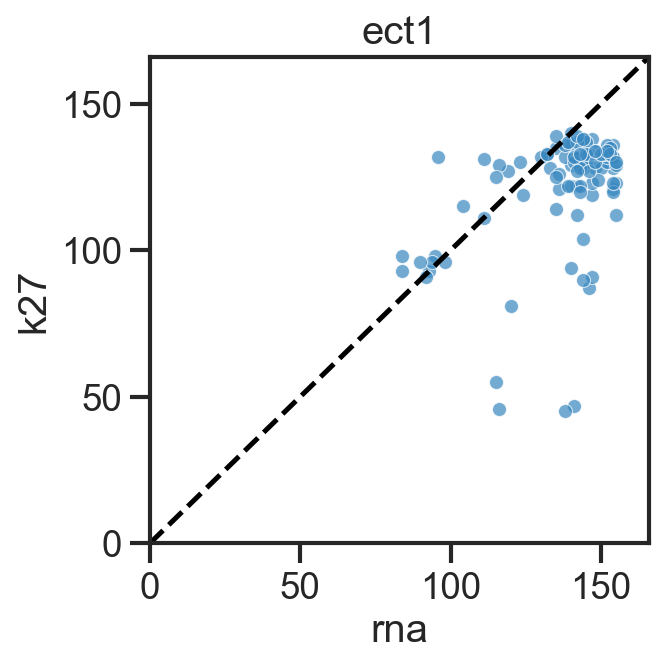

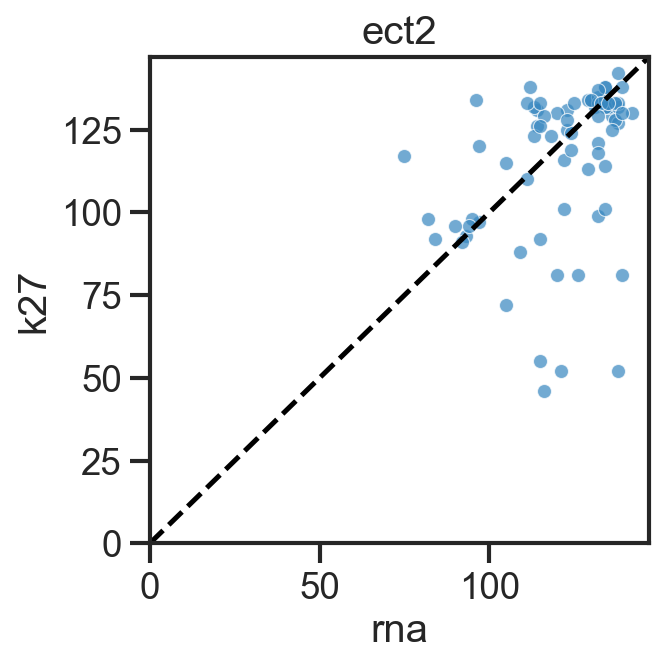

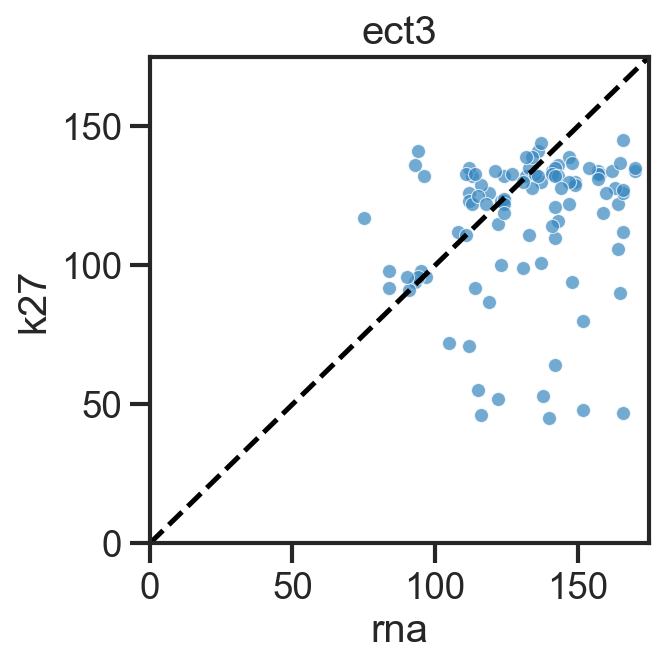

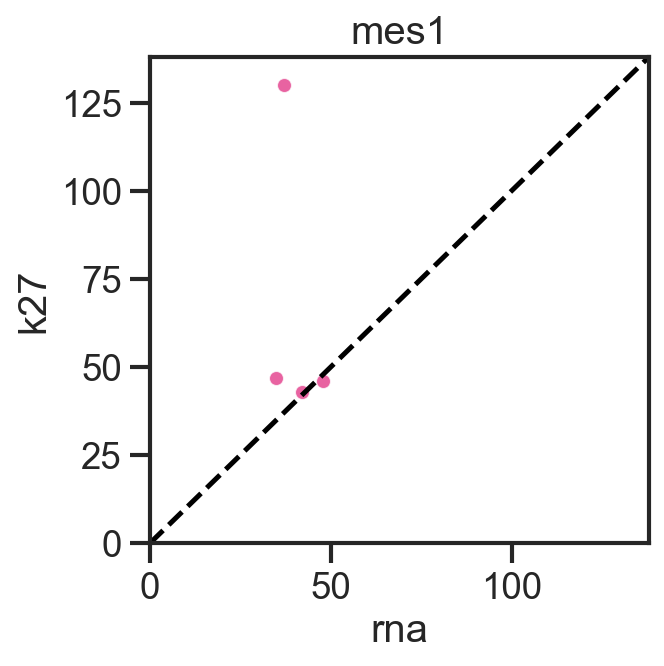

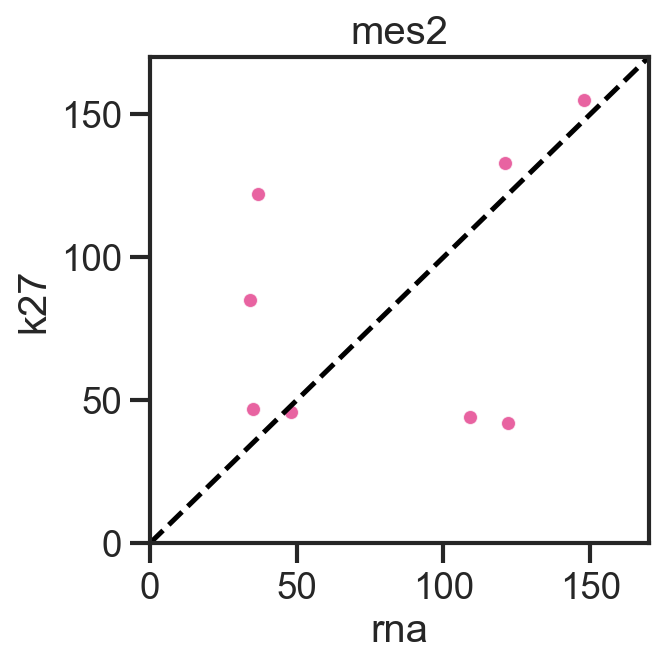

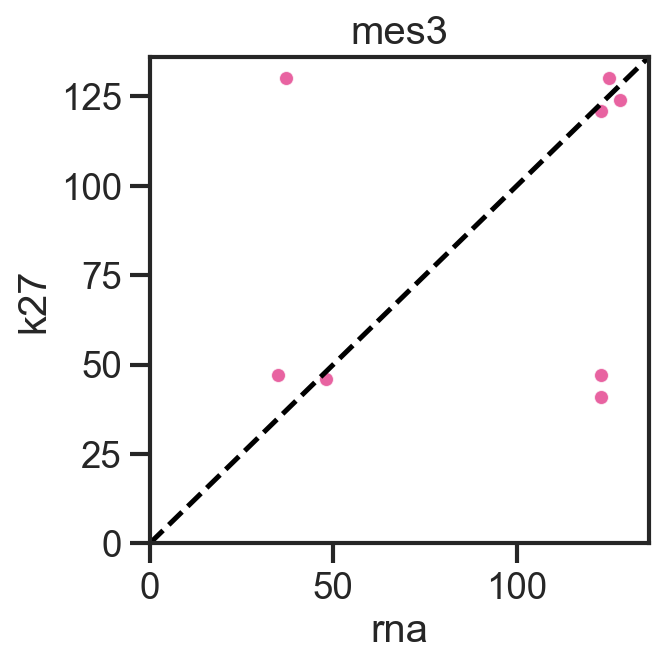

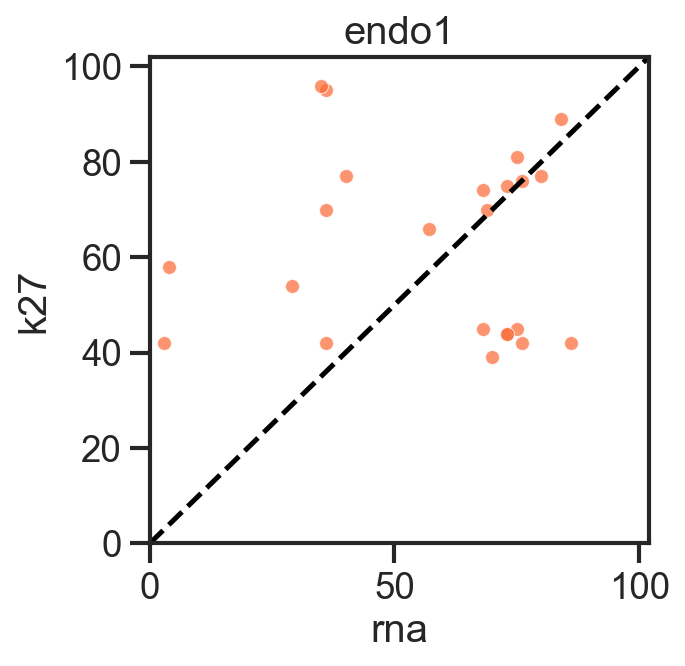

In [563]:
plotRNAvsK27(ect_changes,'ect1',col = 'Ectoderm')
plotRNAvsK27(ect_changes,'ect2',col = 'Ectoderm')
plotRNAvsK27(ect_changes,'ect3',col = 'Ectoderm')

plotRNAvsK27(mes_changes,'mes1',col = 'Mesoderm')
plotRNAvsK27(mes_changes,'mes2',col = 'Mesoderm')
plotRNAvsK27(mes_changes,'mes3',col = 'Mesoderm')

plotRNAvsK27(end_changes,'endo1',col = 'Endoderm')

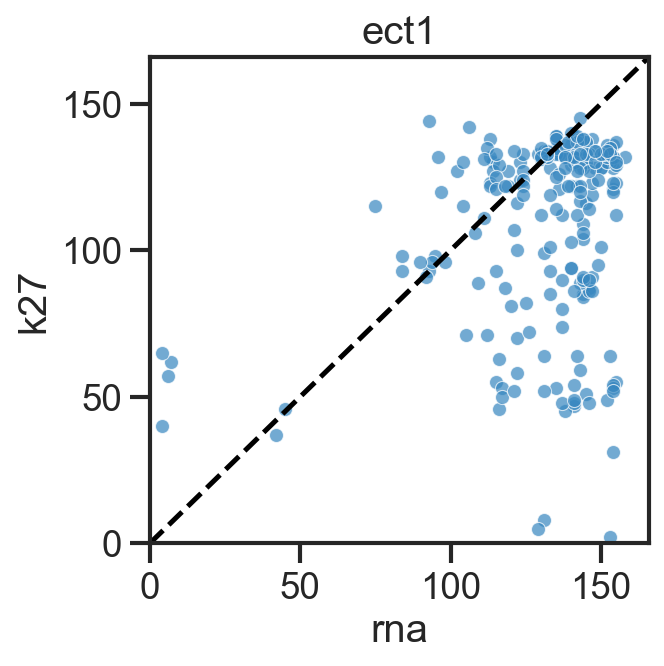

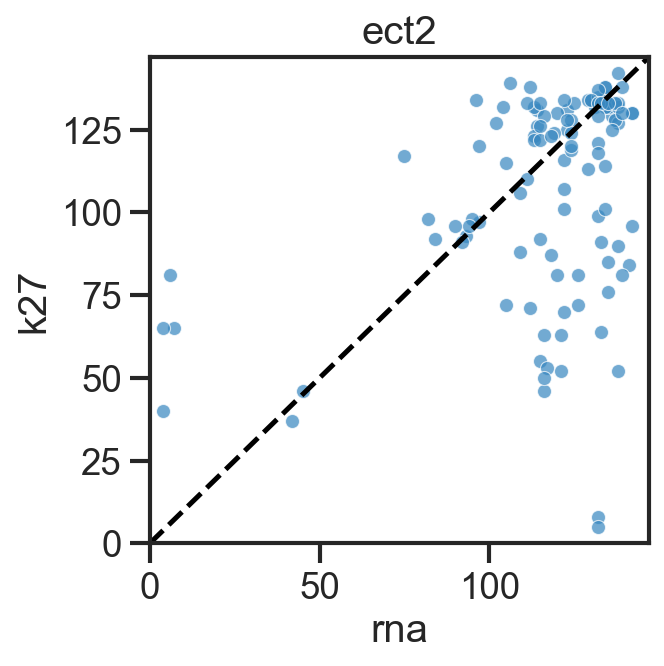

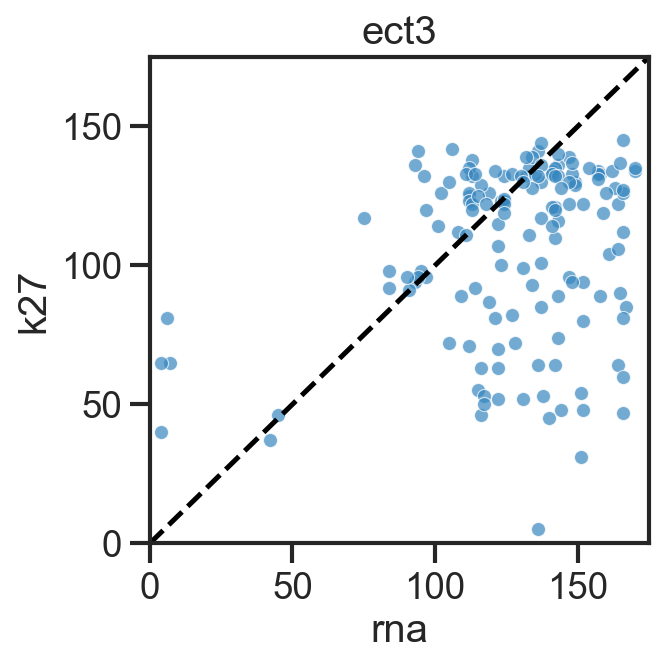

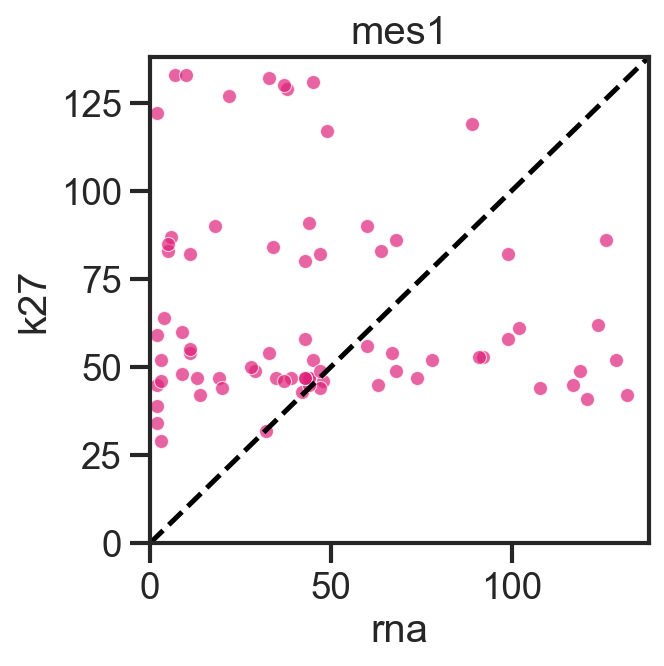

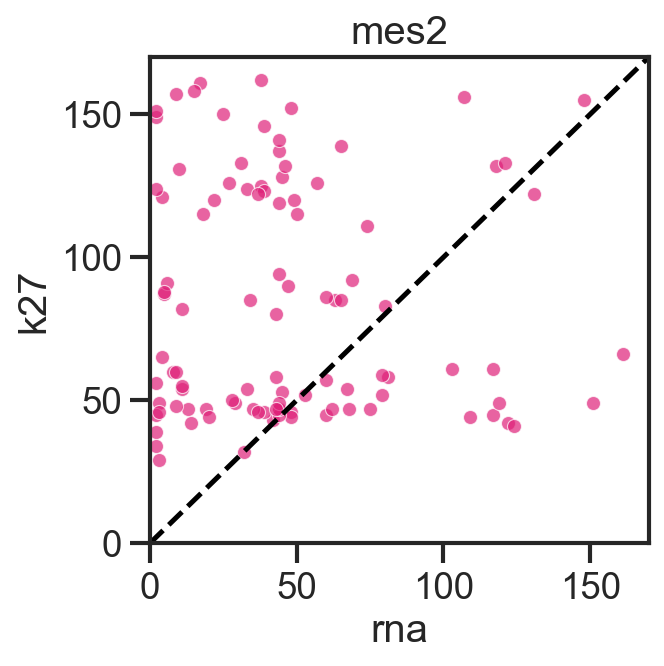

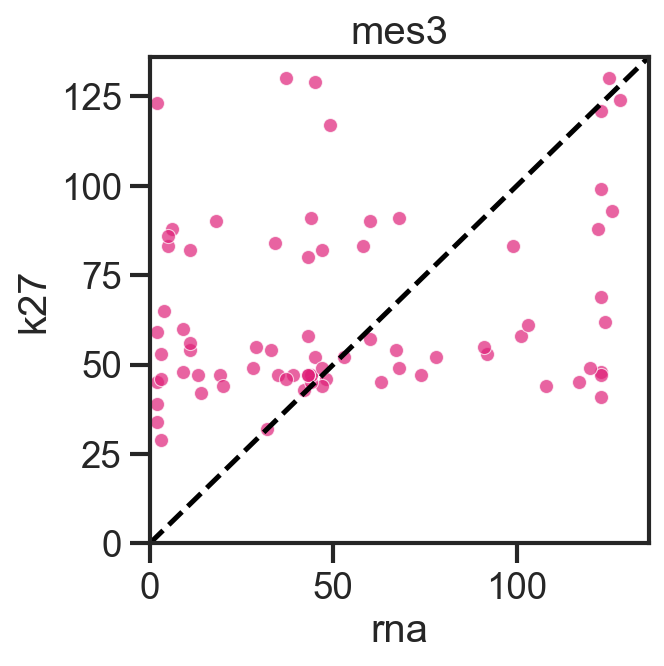

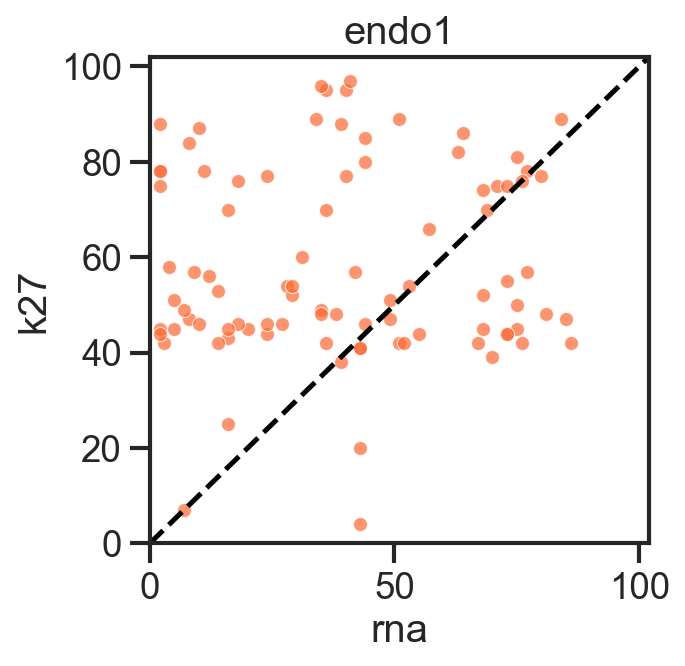

In [610]:
plotRNAvsK27(ect_changes,'ect1',col = 'Ectoderm',keep = 'first', save = 'figs/scatter_rna_vs_k27_ect1.png')
plotRNAvsK27(ect_changes,'ect2',col = 'Ectoderm',keep = 'first', save = 'figs/scatter_rna_vs_k27_ect2.png')
plotRNAvsK27(ect_changes,'ect3',col = 'Ectoderm',keep = 'first', save = 'figs/scatter_rna_vs_k27_ect3.png')

plotRNAvsK27(mes_changes,'mes1',col = 'Mesoderm',keep = 'first', save = 'figs/scatter_rna_vs_k27_mes1.png')
plotRNAvsK27(mes_changes,'mes2',col = 'Mesoderm',keep = 'first', save = 'figs/scatter_rna_vs_k27_mes2.png')
plotRNAvsK27(mes_changes,'mes3',col = 'Mesoderm',keep = 'first', save = 'figs/scatter_rna_vs_k27_mes3.png')

plotRNAvsK27(end_changes,'endo1',col = 'Endoderm',keep = 'first', save = 'figs/scatter_rna_vs_k27_end1.png')

In [542]:
def plotRNAvsK27(df, lin = 'ect1', col = 'Ectoderm', keep = False):
    df['dup'] = df['lin_layer'] + '_' + df['gene']
    df_unique = df[~df['dup'].duplicated(keep = keep)]
    k27 = df_unique[(df_unique['layer'] == 'K27') & (df_unique['lin'] == lin)][['gene','step']].set_index(['gene']).rename(columns={'step':'k27'})
    rna = df_unique[(df_unique['layer'] == 'RNA') & (df_unique['lin'] == lin)][['gene','step']].set_index(['gene']).rename(columns={'step':'rna'})

    plt.axline((1, 1), slope=1, linestyle = 'dashed', c = 'black')
    
    sns.scatterplot(data = rna.join(k27, how = 'inner'),
                    x = 'rna',
                    y = 'k27', s = 40, alpha = 0.7,zorder = 1,
                   color = color_pal[col])
    plt.xlim([0,dict1[lin+'_RNA']+5])
    plt.ylim([0,dict1[lin+'_RNA']+5])
    plt.title(lin)
    plt.show()
    

{'ect1_RNA': np.int64(161),
 'ect2_RNA': np.int64(142),
 'ect3_RNA': np.int64(170),
 'mes1_RNA': np.int64(133),
 'mes2_RNA': np.int64(165),
 'mes3_RNA': np.int64(131),
 'endo1_RNA': np.int64(97),
 'ect1_K4': np.int64(161),
 'ect2_K4': np.int64(142),
 'ect3_K4': np.int64(170),
 'mes1_K4': np.int64(133),
 'mes2_K4': np.int64(165),
 'mes3_K4': np.int64(131),
 'endo1_K4': np.int64(97),
 'ect1_K27': np.int64(161),
 'ect2_K27': np.int64(142),
 'ect3_K27': np.int64(170),
 'mes1_K27': np.int64(133),
 'mes2_K27': np.int64(165),
 'mes3_K27': np.int64(131),
 'endo1_K27': np.int64(97),
 'end1_RNA': np.int64(97)}

In [594]:
def calculateDiff(df, lin = 'ect1', keep = False):
    df['dup'] = df['lin_layer'] + '_' + df['gene']
    df_unique = df[~df['dup'].duplicated(keep = keep)]
    k27 = df_unique[(df_unique['layer'] == 'K27') & (df_unique['lin'] == lin)][['gene','step']].set_index(['gene']).rename(columns={'step':'k27'})
    rna = df_unique[(df_unique['layer'] == 'RNA') & (df_unique['lin'] == lin)][['gene','step']].set_index(['gene']).rename(columns={'step':'rna'})
    joined = rna.join(k27, how = 'inner')
    joined['diff'] = joined['k27']-joined['rna']
    joined['lin'] = lin
    
    return joined

In [595]:
d1 = calculateDiff(ect_changes,'ect1',keep = 'first')
d2 = calculateDiff(ect_changes,'ect2',keep = 'first')
d3 = calculateDiff(ect_changes,'ect3',keep = 'first')

d4 = calculateDiff(mes_changes,'mes1',keep = 'first')
d5 = calculateDiff(mes_changes,'mes2',keep = 'first')
d6 = calculateDiff(mes_changes,'mes3',keep = 'first')

d7 = calculateDiff(end_changes,'endo1',keep = 'first')

In [596]:
d7

,rna,k27,diff,lin
gene,,,,
Slc39a8,11,78,67,endo1
Car4,69,70,1,endo1
Krt8,57,66,9,endo1
Tnfrsf12a,80,77,-3,endo1
Lgals3bp,49,47,-2,endo1
...,...,...,...,...
Crb3,34,89,55,endo1
Sec14l4,14,42,28,endo1
Rhoc,10,87,77,endo1


/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_1833/503014918.py:3: UserWarning: 
The palette list has fewer values (1) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data = pd.concat([d1,d2,d3,d4,d5,d6,d7]),ax=ax,


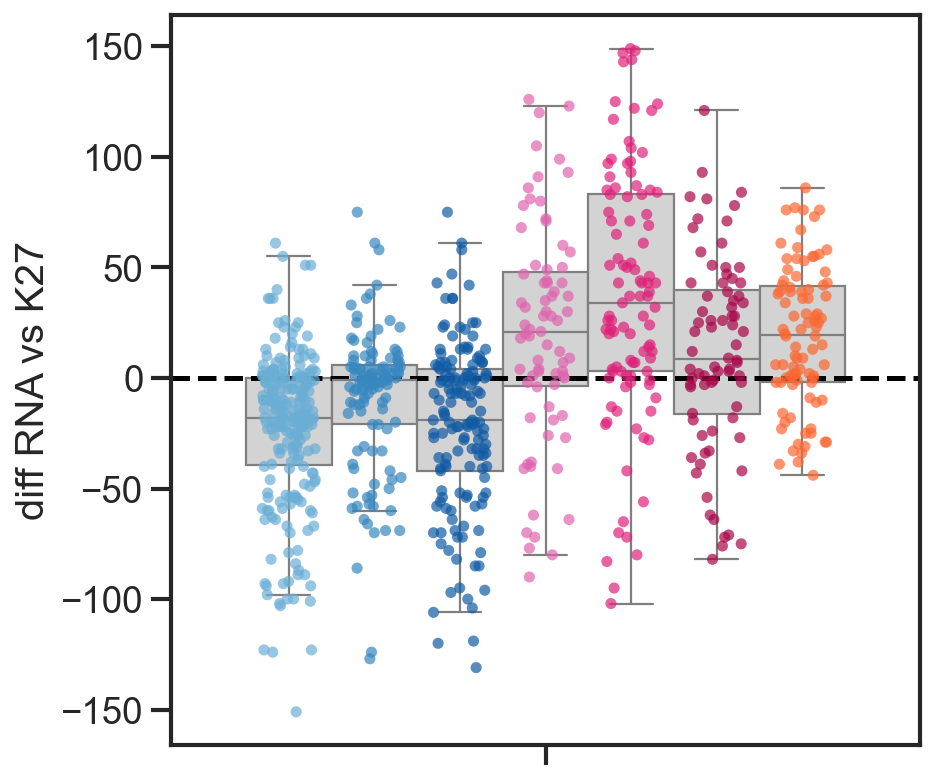

In [608]:
pal = ['#6AAED6', '#3787C0', '#105BA4', '#DF64AF', '#DF2179', '#A90649', '#FC6832',]
fig,ax = plt.subplots(figsize = (6,6))
sns.boxplot(data = pd.concat([d1,d2,d3,d4,d5,d6,d7]),ax=ax,
        y = 'diff', fliersize = False,palette = ['lightgrey'],
            hue = 'lin')
sns.stripplot(data = pd.concat([d1,d2,d3,d4,d5,d6,d7]),ax=ax,
        y = 'diff',palette = pal,dodge = True, size = 5, alpha = 0.7, jitter = 0.25,
            hue = 'lin')
plt.legend([],frameon=False)
plt.axhline(0, linestyle = 'dashed', c = 'black')
plt.ylabel('diff RNA vs K27')
plt.savefig('figs/20250306_barplot_deltaRNAvsK27.png',bbox_inches = 'tight')
plt.show()

ect1


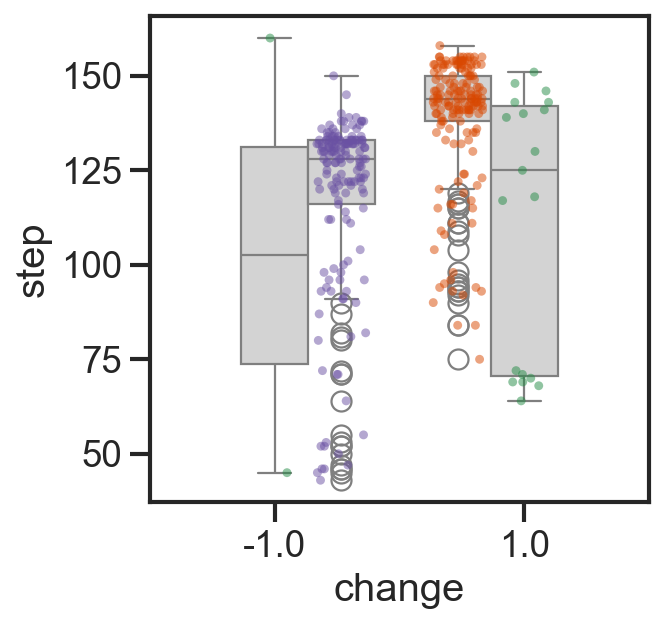

ect3


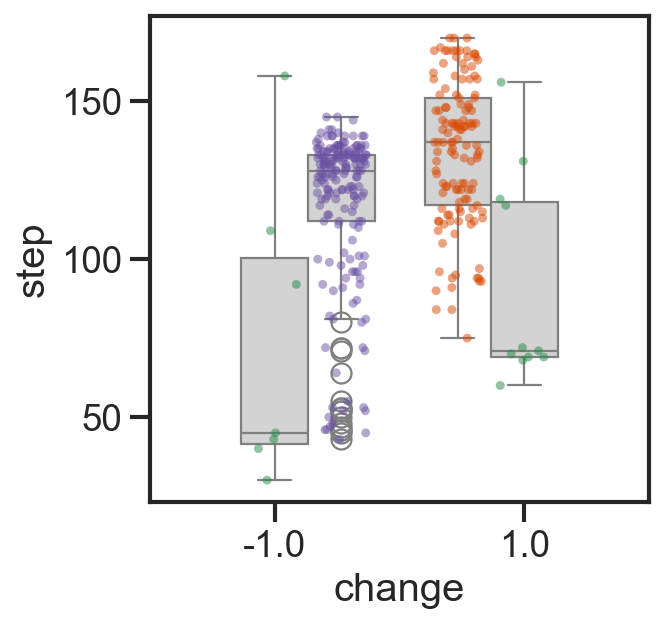

mes2


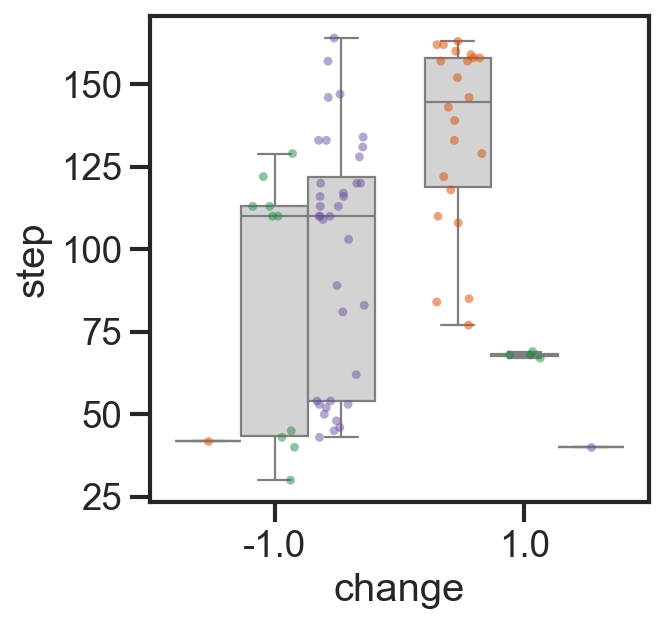

ect2


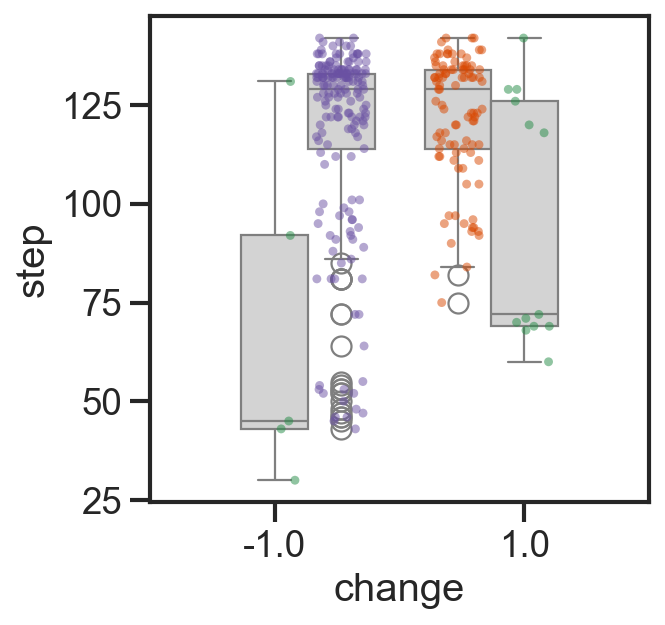

endo1


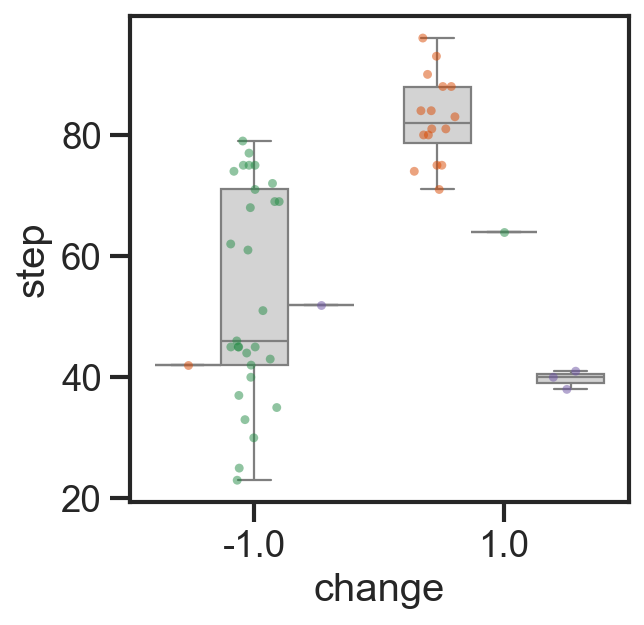

mes1


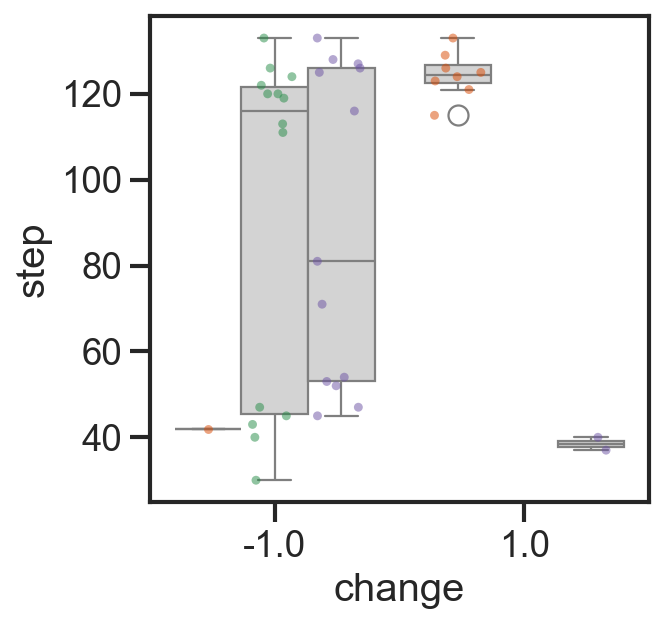

mes3


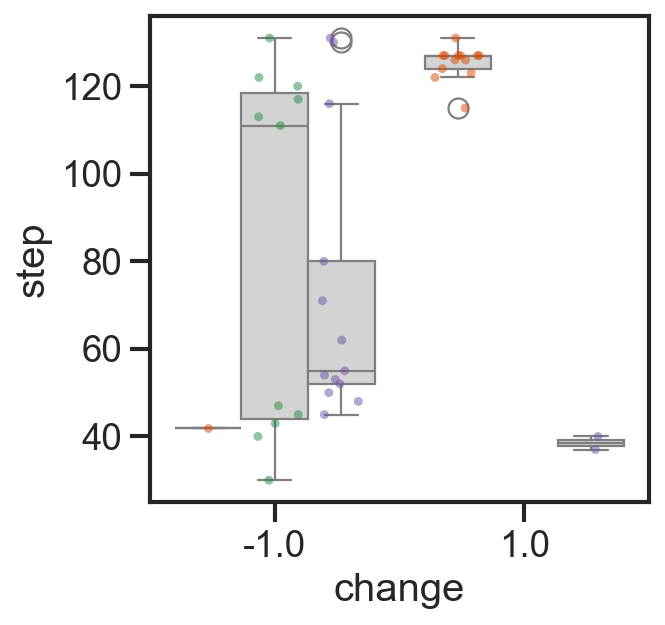

In [424]:
for lins in ect_changes['lin'].unique():
    print(lins)
    sns.stripplot(data = ect_changes_unique[ect_changes_unique['lin'] == lins],
                    y = 'step', palette =[Orange,Green,Purple], hue_order = ['RNA','K4','K27']
                  ,s = 4, alpha = 0.5,# [lightOrange,Orange,lightPurple,Purple,lightGreen,Green], 
                  jitter = 0.3,
                    x = 'change',
                  hue = 'layer',dodge = True)
    sns.boxplot(data = ect_changes_unique[ect_changes_unique['lin'] == lins],
                   y = 'step',palette = ['lightgrey','lightgrey','lightgrey'],
                x = 'change',hue_order = ['RNA','K4','K27'],
                    hue = 'layer', dodge = True)
    plt.legend([],frameon = False)
    plt.show()

In [647]:
def plotChanges(df,lin,keep='first',save = None):
    df['dup'] = df['lin_layer'] + '_' + df['gene']
    df_unique = df[~df['dup'].duplicated(keep = keep)]
    fig,ax = plt.subplots(3,1, figsize = (6,4))
    sns.histplot(df_unique[(df_unique['lin'] == lin) & (df_unique['layer'] == 'RNA')]['step'],
                ax=ax[0], color= Orange, bins=40)
    sns.histplot(df_unique[(df_unique['lin'] == lin) & (df_unique['layer'] == 'K4')]['step'],
                ax=ax[1], color= Green,bins = 40)
    sns.histplot(df_unique[(df_unique['lin'] == lin) & (df_unique['layer'] == 'K27')]['step'],
                ax=ax[2], color= Purple, bins = 40)
    for x in range(3):
        ax[x].set_xlim([0,dict1[lin+'_RNA']+5])
        ax[x].set_xticks([])
        ax[x].set_xlabel('')
        ax[x].set_ylim([0,60])

    if save != None:
        plt.savefig(save,bbox_inches='tight')
    plt.show()

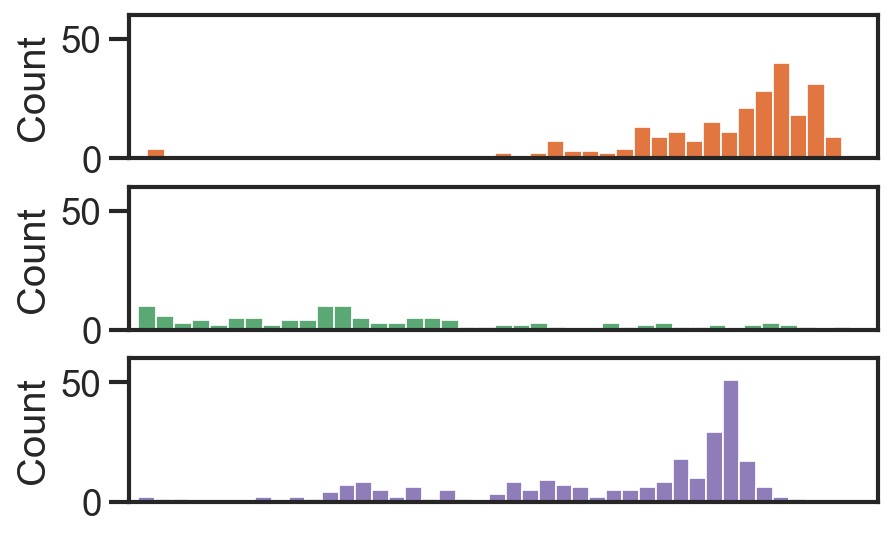

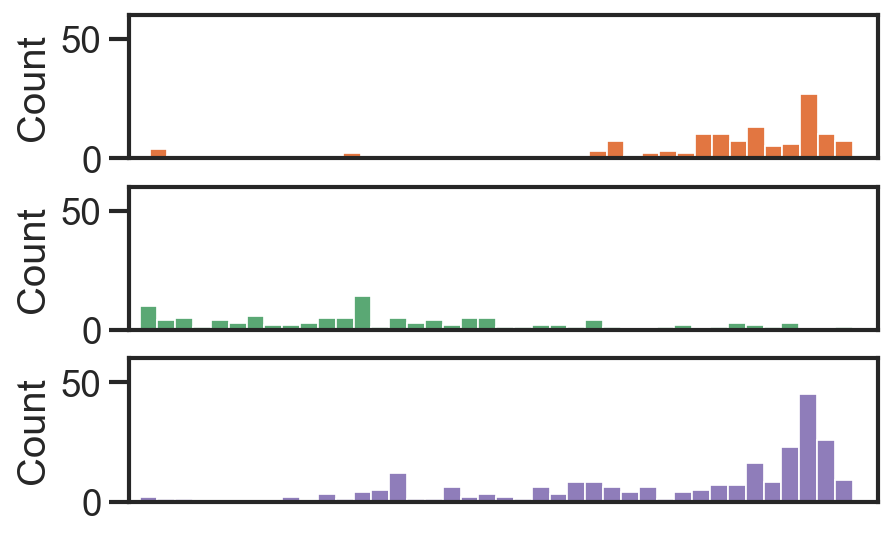

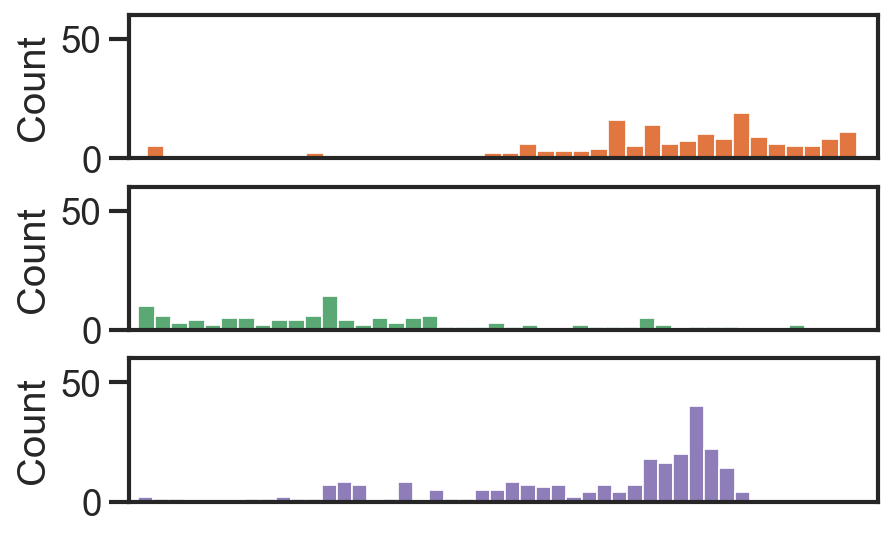

In [648]:
plotChanges(ect_changes,'ect1',save = 'figs/20250306_histplot_changes_ect1.png')
plotChanges(ect_changes,'ect2',save = 'figs/20250306_histplot_changes_ect2.png')
plotChanges(ect_changes,'ect3',save = 'figs/20250306_histplot_changes_ect3.png')

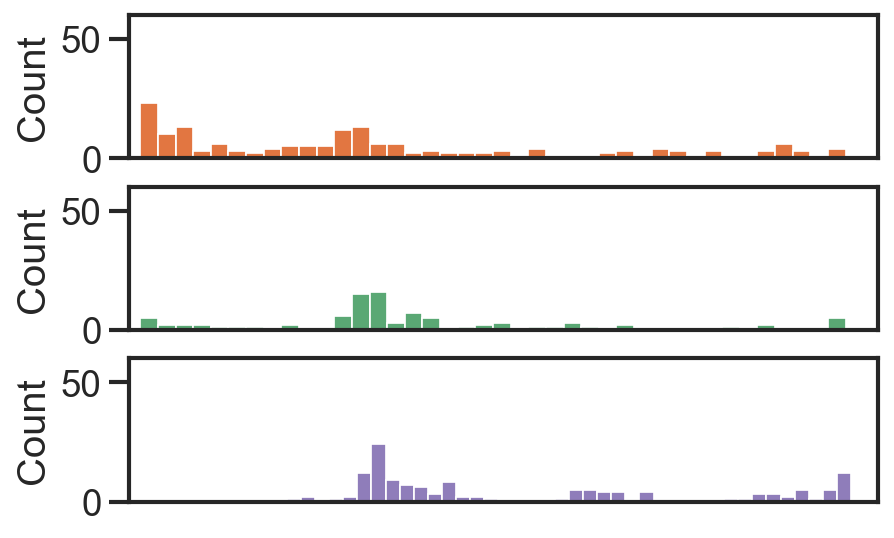

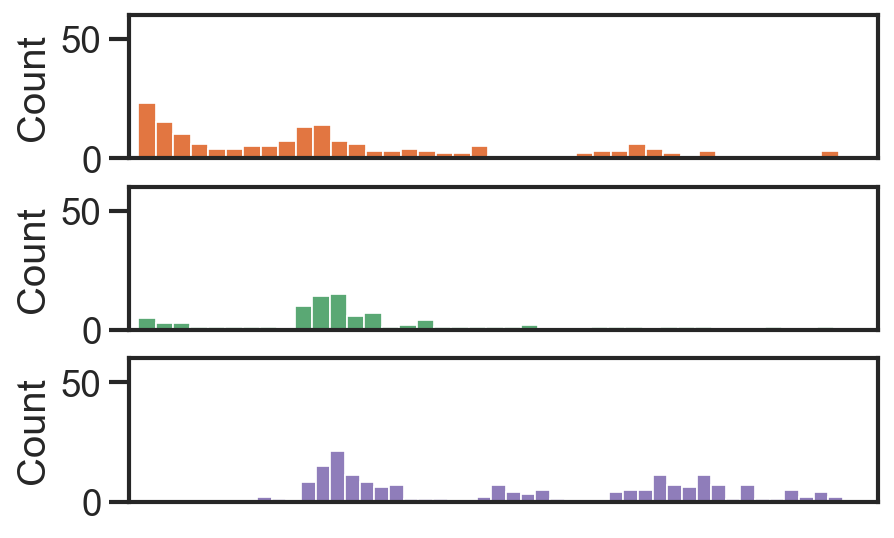

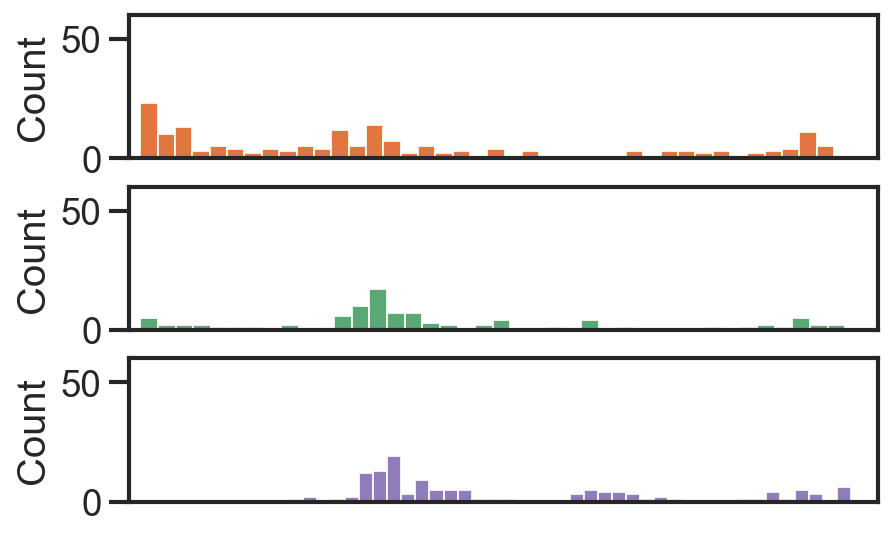

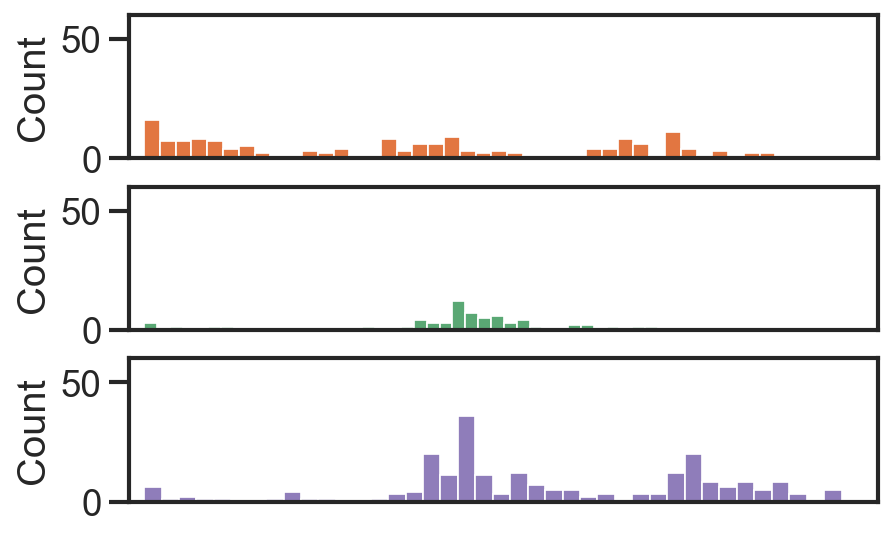

In [649]:
plotChanges(mes_changes,'mes1',save = 'figs/20250306_histplot_changes_mes1.png')
plotChanges(mes_changes,'mes2',save = 'figs/20250306_histplot_changes_mes2.png')
plotChanges(mes_changes,'mes3',save = 'figs/20250306_histplot_changes_mes3.png')
plotChanges(end_changes,'endo1',save = 'figs/20250306_histplot_changes_end1.png')

In [369]:
to_plot1.head(2)

,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,p_99,p_98,p_95,p98_log2,p98_log10,step_id,RT,lin_layer
gene,,,,,,,,,,,,,,,,,
Tnfrsf12a,1,RNA,0.01,ect1,0.014000,-5.643856,-5.380822,0.0,1.0,0.002357,0.003447,0.006167,0.004965,0.001495,1:ect1,mESCs,ect1_RNA
Tnfrsf12a,2,RNA,0.01,ect1,0.011667,-5.643856,-5.528379,0.0,1.0,0.001964,0.002873,0.005140,0.004139,0.001246,2:ect1,mESCs,ect1_RNA


In [372]:
tests = to_plot1[(to_plot1['lin'] == 'endo1') & (to_plot1['layer'] == 'RNA')][['step','sm_short_state_fix','sm_short_state_dyn']]#.loc['Car2']

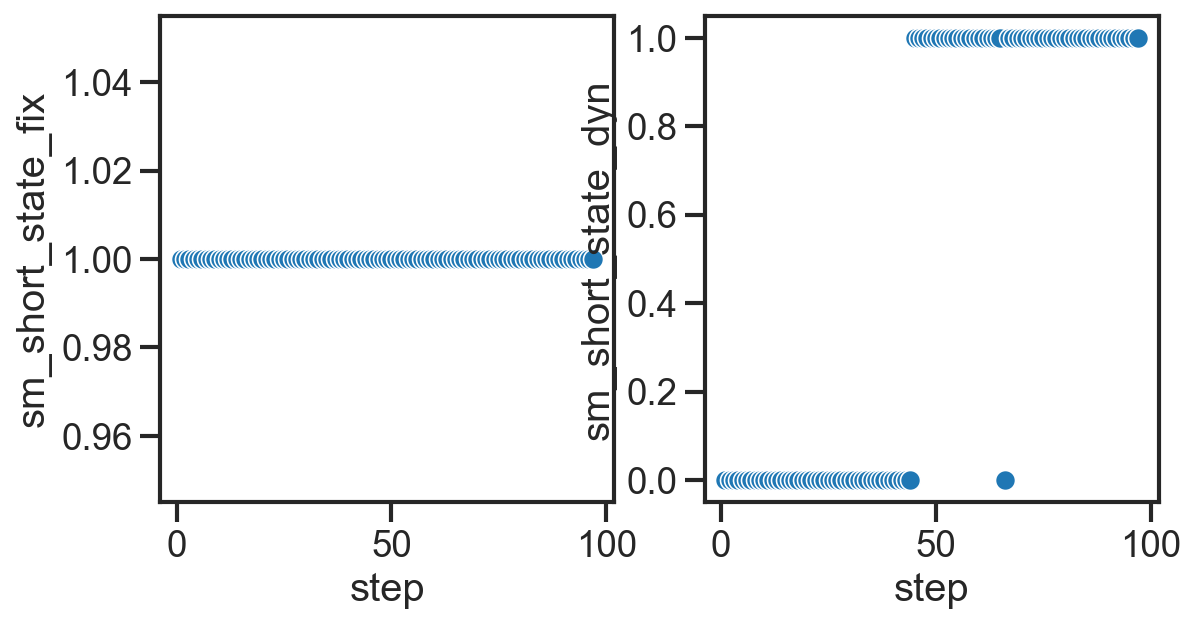

In [376]:
fig, ax = plt.subplots(1,2, figsize = (8,4))
sns.scatterplot(data = tests.loc['Car2'],ax=ax[0],
                x = 'step',
                y = 'sm_short_state_fix')
sns.scatterplot(data = tests.loc['Car2'],ax=ax[1],
                x = 'step',
                y = 'sm_short_state_dyn')
plt.show()

In [378]:
changes[changes['gene']=='Car2']

,step,gene,layer,lin,sm_short_state_fix,change
117,147,Car2,RNA,ect1,0.0,-1.0
118,160,Car2,RNA,ect1,1.0,1.0
119,131,Car2,RNA,mes2,0.0,-1.0
120,149,Car2,RNA,mes2,1.0,1.0
121,160,Car2,RNA,mes2,0.0,-1.0
122,163,Car2,RNA,mes2,1.0,1.0
123,93,Car2,K4,ect1,0.0,-1.0
124,95,Car2,K4,ect1,1.0,1.0
125,141,Car2,K4,ect1,0.0,-1.0
126,145,Car2,K4,ect1,1.0,1.0
